# LAB 02 — N-gram Language Models

Notebook này chạy trên **30K documents** trong `c4-train.00000-of-01024-30K.json.gz`.

> Các cell dưới đây chỉ là pipeline thực nghiệm. Notebook chưa được chạy trong quá trình chuẩn bị deliverable này.


In [24]:
from pathlib import Path
import csv
import math
import pandas as pd
import matplotlib.pyplot as plt

from ngram_lm import (
    load_documents,
    flatten_documents,
    split_documents,
    corpus_statistics,
    frequency_distribution,
    NGramLanguageModel,
    count_unseen_ngrams,
)

DATA_PATH = Path("c4-train.00000-of-01024-30K.json.gz")
RESULTS_PATH = Path("results.csv")

assert DATA_PATH.exists(), f"Không tìm thấy {DATA_PATH}"


## 1. Load 30K documents

In [25]:
# Load the supplied 30K-document corpus.
# Không cần giải nén .gz.
documents = load_documents(DATA_PATH)

print("Documents:", len(documents))
print("First document - number of sentences:", len(documents[0]) if documents else 0)
print("First sentence:", documents[0][0][:30] if documents and documents[0] else [])


Documents: 30000
First document - number of sentences: 8
First sentence: ['beginners', 'bbq', 'class', 'taking', 'place', 'in', 'missoula', '!']


In [26]:
train_docs, validation_docs, test_docs = split_documents(
    documents,
    train_ratio=0.80,
    validation_ratio=0.10,
)

train_corpus = flatten_documents(train_docs)
validation_corpus = flatten_documents(validation_docs)
test_corpus = flatten_documents(test_docs)

print("Train documents:", len(train_docs))
print("Validation documents:", len(validation_docs))
print("Test documents:", len(test_docs))
print("Train sentences:", len(train_corpus))
print("Validation sentences:", len(validation_corpus))
print("Test sentences:", len(test_corpus))


Train documents: 24000
Validation documents: 3000
Test documents: 3000
Train sentences: 513033
Validation sentences: 62305
Test sentences: 61587


## 2. Experiment 1 — Corpus statistics

In [27]:
def add_document_count(stats, docs):
    return {"documents": len(docs), **stats}

train_stats = add_document_count(corpus_statistics(train_corpus), train_docs)
validation_stats = add_document_count(corpus_statistics(validation_corpus), validation_docs)
test_stats = add_document_count(corpus_statistics(test_corpus), test_docs)

stats_df = pd.DataFrame(
    [train_stats, validation_stats, test_stats],
    index=["train", "validation", "test"],
)
stats_df


,documents,sentences,tokens,vocabulary_size,unique_unigrams,unique_bigrams,unique_trigrams,singleton_unigrams,singleton_bigrams,singleton_trigrams
train,24000,513033,10222313,181725,181725,2356866,5896813,89117,1632090,5015802
validation,3000,62305,1234617,51632,51632,466375,872736,23289,342045,778968
test,3000,61587,1211507,50349,50349,457012,854910,22618,334105,761590


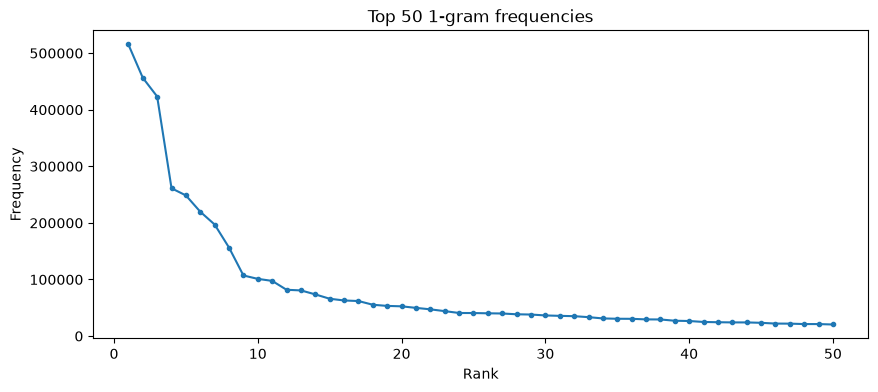

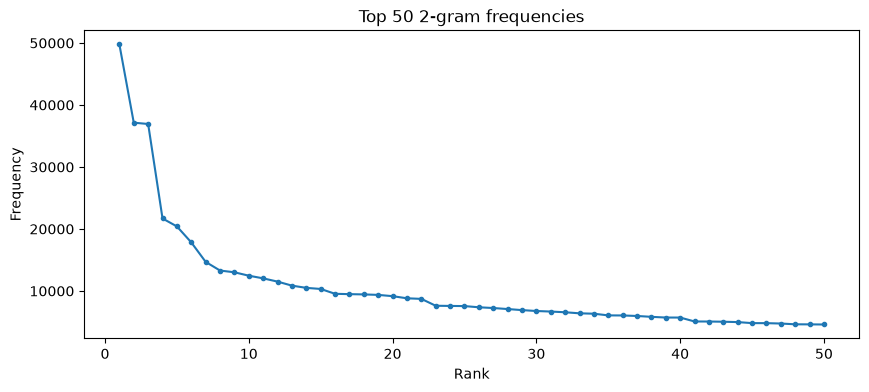

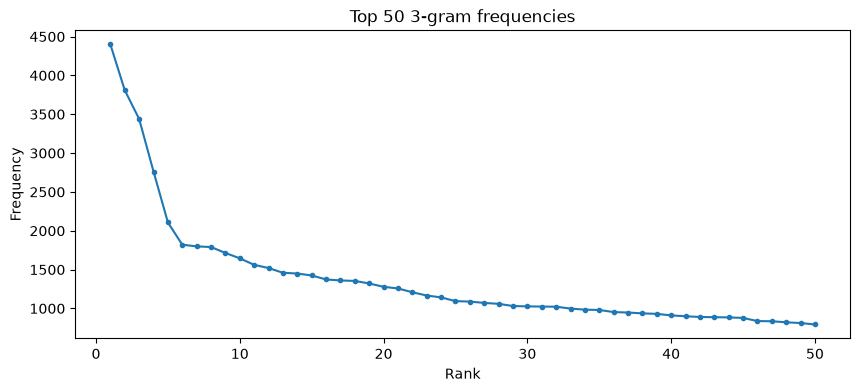

In [28]:
# Frequency distributions on the training corpus.
for n in (1, 2, 3):
    freq = frequency_distribution(train_corpus, n=n)
    counts = sorted(freq.values(), reverse=True)[:50]

    plt.figure(figsize=(10, 4))
    plt.plot(range(1, len(counts) + 1), counts, marker=".")
    plt.xlabel("Rank")
    plt.ylabel("Frequency")
    plt.title(f"Top {len(counts)} {n}-gram frequencies")
    plt.show()


## 3. Train unigram / bigram / trigram models

In [29]:
models = {}

for n in (1, 2, 3):
    models[(n, "none")] = NGramLanguageModel(n=n, smoothing="none").fit(train_corpus)
    models[(n, "laplace")] = NGramLanguageModel(n=n, smoothing="laplace").fit(train_corpus)

print("Models:", list(models))


Models: [(1, 'none'), (1, 'laplace'), (2, 'none'), (2, 'laplace'), (3, 'none'), (3, 'laplace')]


## 4. Section 15 — Log probability

In [30]:
example_sentence = train_corpus[0]

for n in (1, 2, 3):
    model = models[(n, "laplace")]
    print(
        f"n={n}",
        "probability =", model.sentence_probability(example_sentence),
        "log_probability =", model.sentence_log_probability(example_sentence),
    )


n=1 probability = 5.8364876288225324e-39 log_probability = -88.03668944428208
n=2 probability = 4.4390561819309176e-42 log_probability = -95.21813212353952
n=3 probability = 4.722881286353321e-45 log_probability = -102.06391012935453


## 5. Section 16/19 — MLE vs Laplace and perplexity

In [31]:
rows = []

for n in (1, 2, 3):
    for smoothing in ("none", "laplace"):
        model = models[(n, smoothing)]

        rows.append({
            "experiment": "MLE_vs_Laplace_and_PPL",
            "model": f"{n}-gram",
            "smoothing": smoothing,
            "train_ppl": model.perplexity(train_corpus),
            "validation_ppl": model.perplexity(validation_corpus),
            "test_ppl": model.perplexity(test_corpus),
            "note": "",
        })

ppl_df = pd.DataFrame(rows)
ppl_df


,experiment,model,smoothing,train_ppl,validation_ppl,test_ppl,note
0,MLE_vs_Laplace_and_PPL,1-gram,none,inf,inf,inf,
1,MLE_vs_Laplace_and_PPL,1-gram,laplace,2.407001e+03,2.477366e+03,2.487822e+03,
2,MLE_vs_Laplace_and_PPL,2-gram,none,inf,inf,inf,
3,MLE_vs_Laplace_and_PPL,2-gram,laplace,8.296759e+03,1.030737e+04,1.031035e+04,
4,MLE_vs_Laplace_and_PPL,3-gram,none,inf,inf,inf,
5,MLE_vs_Laplace_and_PPL,3-gram,laplace,4.956583e+04,7.787573e+04,7.749978e+04,


## 6. Section 20 — Next-word prediction

In [32]:
# Section 20 — Next-word prediction with actual next word and probability

def find_actual_next_word(context_tokens, documents):
    """
    Find the first occurrence of context in validation documents
    and return the word immediately following it.
    """
    for doc in documents:
        for sentence in doc:
            tokens = sentence

            for i in range(len(tokens) - len(context_tokens)):
                if tokens[i:i + len(context_tokens)] == context_tokens:
                    return tokens[i + len(context_tokens)]

    return None


prediction_contexts = [
    "the",
    "in the",
    "one of the",
    "this is",
    "there are",
    "a lot of",
    "as well as",
    "according to the",
    "at the end",
    "part of the",
    "one of",
    "the first",
    "the United",
    "in a",
    "for the",
    "with the",
    "it is",
    "they are",
    "we have",
    "he was",
]

prediction_rows = []

# Use the trigram Laplace model, as in the original experiment
model = models[(3, "laplace")]

for context_text in prediction_contexts:
    context_tokens = context_text.lower().split()

    # Model prediction
    top = model.next_word_distribution(
        context_tokens,
        top_k=5
    )

    predicted_word = top[0][0] if top else None
    predicted_probability = top[0][1] if top else None

    # Actual next word from validation corpus
    actual_word = find_actual_next_word(
        context_tokens,
        validation_docs
    )

    # Probability assigned by model to the actual word
    actual_probability = None

    if actual_word is not None:
        actual_probability = model.probability(
            context_tokens,
            actual_word
        )

    prediction_rows.append({
        "context": context_text,
        "model_prediction": predicted_word,
        "prediction_probability": predicted_probability,
        "actual_next_word": actual_word,
        "actual_probability": actual_probability,
        "top_5": top,
    })

prediction_df = pd.DataFrame(prediction_rows)

prediction_df

,context,model_prediction,prediction_probability,actual_next_word,actual_probability,top_5
0,the, ,0.000006,los,0.000006,"[( , 5.5027596339564294e-06), (, 5.5027596339..."
1,in the,world,0.003631,los,0.000046,"[(world, 0.003631191661979045), (past, 0.00236..."
2,one of the,most,0.004238,last,0.000320,"[(most, 0.004237892199427172), (best, 0.002501..."
3,this is,a,0.006441,already,0.000037,"[(a, 0.006441438321496502), (the, 0.0044541293..."
4,there are,many,0.002400,a,0.002325,"[(many, 0.0024001546408359197), (a, 0.00232498..."
5,a lot of,people,0.000729,work,0.000207,"[(people, 0.0007285697197725123), (time, 0.000..."
6,as well as,the,0.002354,blue,0.000005,"[(the, 0.0023543133612683054), (a, 0.001355350..."
7,according to the,next,0.000909,analysis,0.000039,"[(next, 0.0009094529026295479), (top, 0.000909..."
8,at the end,of,0.005938,of,0.005938,"[(of, 0.0059384883847747845), (,, 0.0006761915..."
9,part of the,most,0.004238,master,0.000039,"[(most, 0.004237892199427172), (best, 0.002501..."


In [33]:
# Get the cases where the model predicted the correct next word
correct_predictions = prediction_df[
    prediction_df["model_prediction"] == prediction_df["actual_next_word"]
].copy()

print("Correct predictions:")
display(
    correct_predictions[
        [
            "context",
            "model_prediction",
            "prediction_probability",
            "actual_next_word",
            "actual_probability"
        ]
    ]
)

Correct predictions:


,context,model_prediction,prediction_probability,actual_next_word,actual_probability
8,at the end,of,0.005938,of,0.005938
11,the first,time,0.003195,time,0.003195
12,the United,states,0.005183,states,0.005183
14,for the,first,0.002525,first,0.002525
16,it is,a,0.005124,a,0.005124


In [34]:
# Get the cases where the model predicted the wrong next word
incorrect_predictions = prediction_df[
    prediction_df["model_prediction"] != prediction_df["actual_next_word"]
].copy()

print("Incorrect predictions:")
display(
    incorrect_predictions[
        [
            "context",
            "model_prediction",
            "prediction_probability",
            "actual_next_word",
            "actual_probability"
        ]
    ]
)

Incorrect predictions:


,context,model_prediction,prediction_probability,actual_next_word,actual_probability
0,the, ,0.000006,los,0.000006
1,in the,world,0.003631,los,0.000046
2,one of the,most,0.004238,last,0.000320
3,this is,a,0.006441,already,0.000037
4,there are,many,0.002400,a,0.002325
5,a lot of,people,0.000729,work,0.000207
6,as well as,the,0.002354,blue,0.000005
7,according to the,next,0.000909,analysis,0.000039
9,part of the,most,0.004238,master,0.000039
10,one of,the,0.020260,their,0.000431


## 7. Section 21 — Sentence ranking


In [35]:
ranking_context = ["the", "language"]
candidates = [
    "model predicts words",
    "model uses context",
    "model is useful",
]

ranking = models[(3, "laplace")].rank_candidates(
    ranking_context,
    candidates,
)
ranking


[('model predicts words', -36.331569109282825),
 ('model uses context', -36.331569109282825),
 ('model is useful', -36.33206973232139)]

## 8. Section 23 — Context length


In [36]:
context_rows = []

for n in (1, 2, 3):
    model = models[(n, "laplace")]
    context_rows.append({
        "n": n,
        "train_ppl": model.perplexity(train_corpus),
        "validation_ppl": model.perplexity(validation_corpus),
        "test_ppl": model.perplexity(test_corpus),
        "unique_train_ngrams": len(frequency_distribution(train_corpus, n)),
        "unseen_validation_ngrams": count_unseen_ngrams(train_corpus, validation_corpus, n),
        "unseen_test_ngrams": count_unseen_ngrams(train_corpus, test_corpus, n),
    })

context_df = pd.DataFrame(context_rows)
context_df


,n,train_ppl,validation_ppl,test_ppl,unique_train_ngrams,unseen_validation_ngrams,unseen_test_ngrams
0,1,2407.001238,2477.366157,2487.821554,181725,12602,12478
1,2,8296.758601,10307.370587,10310.351148,2356866,206175,201904
2,3,49565.834923,77875.727407,77499.777550,5896813,620210,606532


## 9. Save experimental results

Chạy cell này **sau khi đã chạy toàn bộ experiment** để cập nhật `results.csv`.


In [37]:
# Save the main perplexity table.

# Copy the existing prediction results
prediction_results = prediction_df[
    [
        "context",
        "model_prediction",
        "prediction_probability",
        "actual_next_word",
        "actual_probability"
    ]
].copy()

prediction_results["result_type"] = "prediction"

# Copy the existing perplexity results
ppl_results = ppl_df.copy()
ppl_results["result_type"] = "perplexity"

# Add missing columns to each DataFrame
for col in ppl_results.columns:
    if col not in prediction_results.columns:
        prediction_results[col] = None

for col in prediction_results.columns:
    if col not in ppl_results.columns:
        ppl_results[col] = None

# Put both results into one DataFrame
results_df = pd.concat(
    [ppl_results, prediction_results],
    ignore_index=True
)

# Save the combined results
results_df.to_csv(RESULTS_PATH, index=False)

print(f"Saved: {RESULTS_PATH.resolve()}")
print(f"Total result rows: {len(results_df)}")


Saved: C:\Users\ADMIN\NLP_Apps_Labs\lab02\results.csv
Total result rows: 26
